
<center><font size=6>Movie Review Sentiment Analysis: Word2Vec vs. Sentence Transformers</center></font>

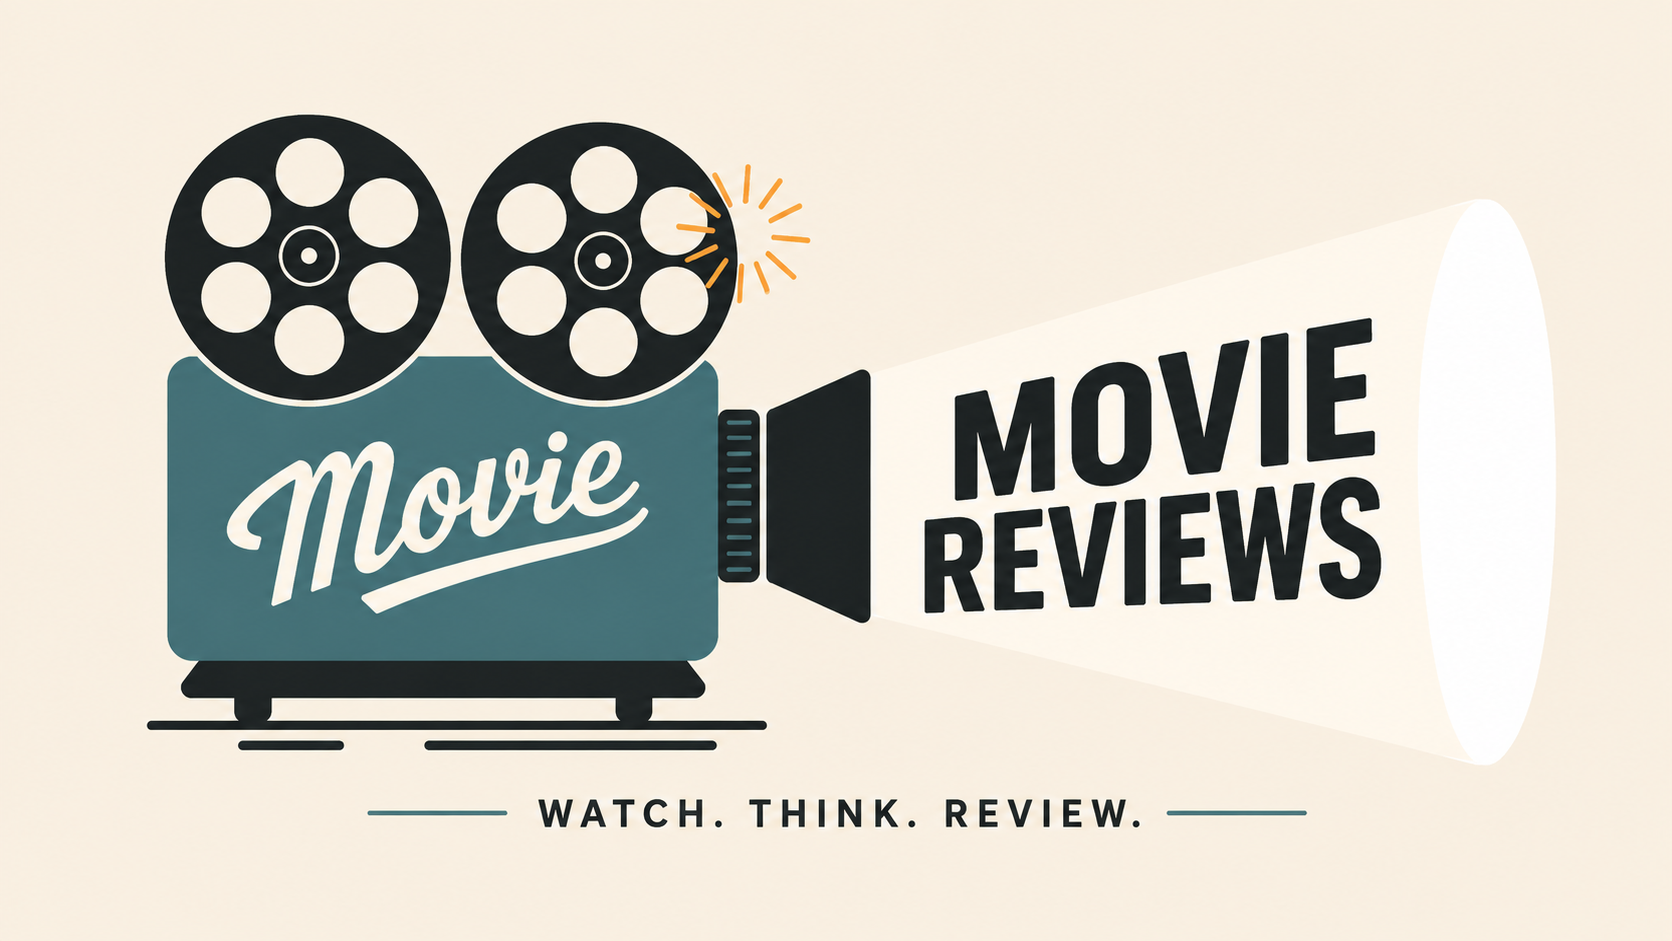

# **Problem Statement**

- The entertainment industry needs a fast, reliable way to understand how audiences feel about movie releases.
- Reading thousands of reviews manually is slow and can miss subtle sentiment.
- **Goal:** build an AI-based sentiment analyzer that automatically classifies movie reviews as positive or negative, giving quick, actionable insight into audience opinion.

## **Data Dictionary**

- **review**: review of a movie
- **sentiment**: indicates the sentiment of the review ( 0 is for negative review and 1 for positive review)

# **Installing and Importing Necessary Libraries**

In [ ]:
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2\
             accelerate==1.7.0\
             sentencepiece==0.2.0

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# **Loading the dataset**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
reviews = pd.read_csv("/content/drive/MyDrive/GenAi/movie_review.csv")

In [ ]:
# creating a copy of the data
data = reviews.copy()

# **Data Overview**

## **Checking the first 5 rows**

In [ ]:
data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

* Here, a sentiment value of **0 is negative** and **1 is positive**.

## **Checking the shape of the data**

In [ ]:
data.shape

(9982, 2)

* The dataset has almost 10000 rows and 2 columns.

## **Checking for missing values**

In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


* There are no missing values in the data

## **Checking for duplicate values**

In [ ]:
# checking for duplicate values
data.duplicated().sum()

0

## **Checking the distribution of sentiments**

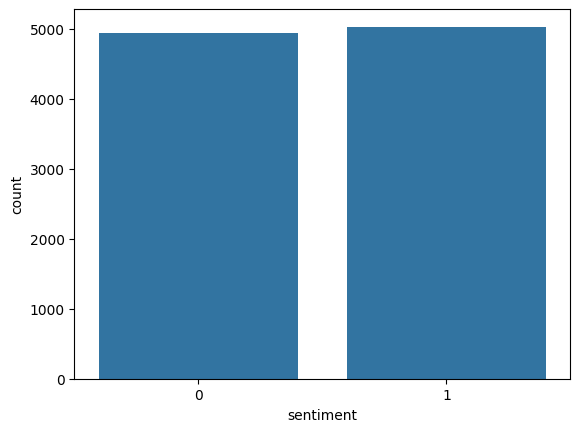

In [ ]:
sns.countplot(data=data, x='sentiment');

- There are almost an equal number of positive and negative reviews.

# **Text Embedding and Sentiment Analysis: Word2Vec**

## **Generating Embeddings with Word2Vec**

- `Word2Vec` (from Gensim) turns words into numeric vectors that capture meaning based on the context they appear in.
- Key parameters:
    - `word_list`: list of all words in the documents
    - `vector_size`: length of each word vector (default 100)
    - `min_count`: ignores words below this frequency
    - `window`: size of the context window around a target word
    - `workers`: number of threads used for training

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['review'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 157460


This vocabulary size reflects every unique word Word2Vec learned from our reviews - since `min_count=1`, even rare words were kept.

### **Basic Examples**

In [ ]:
model_W2V.wv["good"]

array([ 1.14224386e+00,  1.16967046e+00, -7.38275707e-01,  4.27431166e-01,
        5.34802914e-01, -1.70291293e+00,  1.15825200e+00,  1.00733340e+00,
       -1.29899001e+00,  3.62884514e-02,  3.67539138e-01, -1.33544612e+00,
       -4.71181184e-01,  7.50298023e-01, -1.23043978e+00,  1.10501654e-01,
        2.13562205e-01,  5.56732109e-03, -4.54127878e-01, -1.05635977e+00,
        1.00175047e+00, -2.80798763e-01,  8.14711332e-01,  1.31402218e+00,
       -2.76664317e-01, -1.28361320e+00, -1.22656322e+00, -1.59699333e+00,
       -2.34606147e+00, -1.33977890e+00,  5.65582573e-01, -3.17028821e-01,
       -1.56604782e-01,  6.25217915e-01,  2.87625432e-01, -7.07677186e-01,
       -3.78831595e-01, -3.96894813e-01,  1.02885473e+00,  7.44599998e-01,
        2.54030436e-01, -5.83210528e-01, -3.12009692e-01,  1.13250506e+00,
        9.66412365e-01, -3.98117602e-01, -1.29851103e-01,  1.00003672e+00,
        5.51221371e-01,  5.41948617e-01, -6.15865171e-01, -1.05230501e-02,
        8.09162498e-01, -

In [ ]:
model_W2V.wv["best"]

array([ 7.94593766e-02,  1.16000704e-01, -6.99605346e-01,  3.84977669e-01,
        7.00639248e-01, -2.69036770e-01,  8.52124631e-01,  8.17145467e-01,
       -2.08057904e+00,  1.97888929e-02,  2.97866315e-01, -1.04968870e+00,
       -2.20680380e+00,  1.03351629e+00, -5.10285139e-01, -2.50979066e-01,
        1.50089324e+00, -9.78293061e-01, -4.03049320e-01, -2.72713929e-01,
        1.24777853e+00,  1.15408969e+00,  6.41535103e-01,  3.54589671e-02,
        3.30763936e-01, -1.38676226e+00, -7.58196473e-01, -3.85293603e-01,
       -1.01870336e-01, -1.91999090e+00,  6.34387970e-01,  7.55427957e-01,
       -7.88875043e-01,  1.10046923e+00,  6.26238108e-01, -2.70752132e-01,
        7.25244224e-01, -1.00866413e+00,  1.25338459e+00,  3.15870881e-01,
       -8.78412247e-01,  3.91607940e-01,  1.38048604e-02,  3.03345174e-01,
        9.72536445e-01, -7.97842622e-01, -2.33435288e-01,  5.00727296e-01,
        3.41605186e-01,  9.69817042e-01, -8.81009281e-01,  1.06882858e+00,
        8.91229391e-01,  

Each word is now a list of 300 numbers, and similar words end up with similar vectors - but a single word vector alone isn't very useful; next we combine word vectors into one vector per review.

### **Encoding the dataset**

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['review'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.358920,-0.226720,-0.361210,-0.099626,0.090581,-0.431533,0.524014,0.695735,-0.075986,-0.095123,...,0.058463,0.555934,0.319787,0.211996,0.717844,0.566332,0.038222,-0.364117,0.433572,-0.130500
1,0.259033,-0.074117,-0.262925,-0.197060,0.141579,-0.358067,0.517583,0.644941,-0.161806,-0.113593,...,0.144503,0.404288,0.144390,0.090479,0.431584,0.552340,-0.032583,-0.302373,0.425407,-0.327529
2,0.356476,-0.069154,-0.304250,-0.068873,0.150268,-0.466774,0.519224,0.685749,-0.158945,-0.116357,...,0.073709,0.372028,0.173148,0.039557,0.482985,0.550917,-0.007605,-0.235097,0.438538,-0.312699
3,0.344085,-0.092355,-0.291248,-0.241444,0.178916,-0.294459,0.664141,0.643164,-0.094893,-0.163029,...,0.139738,0.351259,0.013569,0.064019,0.425358,0.625529,-0.040560,-0.155826,0.449038,-0.221842
4,0.386318,-0.130325,-0.340331,-0.206854,0.144365,-0.387485,0.780069,0.674611,-0.064702,-0.122569,...,0.129847,0.283982,0.080162,-0.004459,0.478490,0.675946,0.014670,-0.309951,0.516189,-0.263440


Each review is now one 300-number vector, found by averaging the vectors of all its words - this turns raw text into a format a machine learning model can use.

## **Sentiment Analysis with Random Forest**

In [ ]:
# Define a function to plot the confusion matrix
def plot_confusion_matrix(actual, predicted):
    # Calculate the confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Create a figure for the plot
    plt.figure(figsize = (5, 4))
    # Define labels for the plot axes
    label_list = ['negative', 'positive']
    # Create a heatmap of the confusion matrix
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    # Set the y-axis label
    plt.ylabel('Actual')
    # Set the x-axis label
    plt.xlabel('Predicted')
    # Display the plot
    plt.show()

In [ ]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.sentiment

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

**Confusion Matrix**

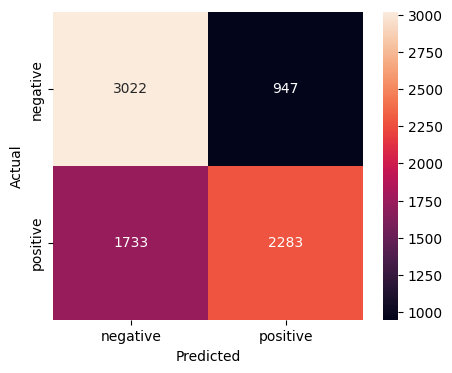

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

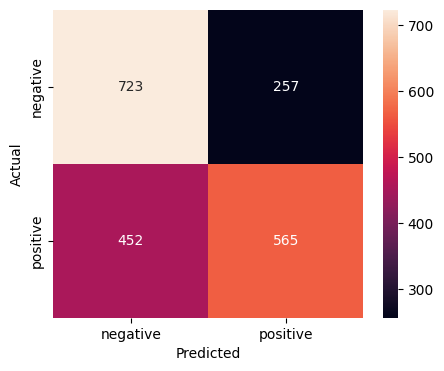

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

The confusion matrix shows a large number of misclassifications on the test set, confirming the model struggles to separate positive and negative reviews.

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)

The accuracy on the training set is:  0.6643706950532248
The accuracy on the test set is:  0.6449674511767651


Train and test accuracy are both low and close to each other, which points to underfitting rather than overfitting - the model isn't learning strong patterns from these embeddings.

## **Sentiment Analysis with Neural Networks**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,914 (183.26 KB)

 Trainable params: 46,914 (183.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5887 - loss: 0.6668 - val_accuracy: 0.6395 - val_loss: 0.6295
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6526 - loss: 0.6235 - val_accuracy: 0.6895 - val_loss: 0.5921
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6784 - loss: 0.5945 - val_accuracy: 0.6895 - val_loss: 0.5844
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6974 - loss: 0.5823 - val_accuracy: 0.7016 - val_loss: 0.5848
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7016 - loss: 0.5825 - val_accuracy: 0.7091 - val_loss: 0.5617
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7086 - loss: 0.5683 - val_accuracy: 0.7046 - val_loss: 0.5678
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7128 - loss: 0.5662 - val_accuracy: 0.6830 - val_loss: 0.5999
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7108 - loss: 0.5635 - val_accuracy: 0.

### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


**Confusion Matrix**

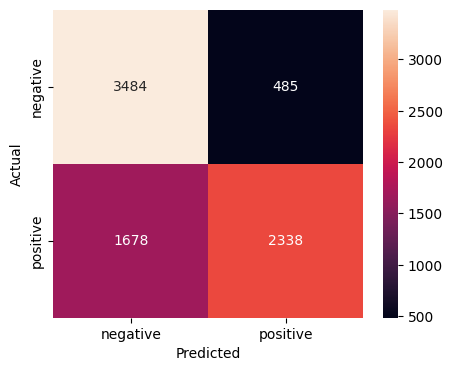

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

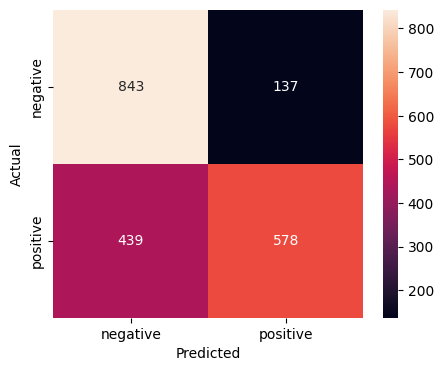

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

The confusion matrix shows fewer errors than the Random Forest version, suggesting the neural network picks up slightly more signal from the Word2Vec embeddings.

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.7291170945522856
The accuracy on the test set is:  0.7115673510265398


Accuracy has improved over the Random Forest model, but there's still room to grow since Word2Vec embeddings don't capture full sentence context.

# **Text Embedding and Sentiment Analysis: Transformers**

## **Generating Embeddings with Sentence Tranformers**

We'll use the **all-MiniLM-L6-v2** model here.

- Trained on 1B+ sentence pairs, it produces compact 384-dimension sentence embeddings.
- It has 6 transformer layers - much smaller than BERT, but built to match its performance.
- Useful for text classification, sentiment analysis, and semantic search.

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

- There are many other models to choose from too!
- One place to check for the best models is the [HuggingFace leaderboard](https://www.sbert.net/docs/pretrained_models.html).
- Below is an example of another model that one can use in this case.

> `model = SentenceTransformer('BAAI/bge-base-en-v1.5')`

### **Basic Examples**

In [ ]:
model.encode(['Hello, my name is Prof. Zena!'])

array([[-1.01322234e-01,  2.77659073e-02, -4.15140204e-02,
         1.84561070e-02, -4.85774986e-02, -1.63206700e-02,
         1.31670877e-01, -2.84867790e-02,  2.94029317e-03,
        -2.18541399e-02, -5.48135974e-02, -9.36227106e-03,
        -1.48072606e-02,  2.78399717e-02, -3.74657139e-02,
        -4.98631154e-04, -6.98259613e-03, -2.66996957e-02,
        -3.89730968e-02, -2.10850555e-02, -9.75726731e-03,
        -1.97303691e-03,  5.53301685e-02, -3.02358363e-02,
        -7.95633346e-02, -1.13197388e-02, -1.35751115e-02,
         1.47868479e-02, -3.55503289e-03, -7.07180947e-02,
         2.56204512e-02,  6.83853552e-02,  2.18798202e-02,
        -1.32916204e-03,  5.71828224e-02,  5.70111796e-02,
        -6.20051436e-02, -1.44120632e-02,  7.99199753e-03,
         7.58335576e-04,  1.20889395e-03,  6.11672876e-03,
        -8.94942135e-02, -3.09464079e-03, -5.15797585e-02,
        -4.05938700e-02,  6.07262813e-02, -1.10700903e-02,
         6.72289953e-02, -3.69399339e-02, -9.92941558e-0

In [ ]:
model.encode(['Hello, my name is Professor Zena!'])

array([[-1.11282609e-01,  4.16151471e-02, -4.53359000e-02,
         1.95421167e-02, -6.02430180e-02, -3.59271467e-02,
         9.60513875e-02, -5.55648692e-02,  2.31815521e-02,
        -6.68980787e-03, -2.75410414e-02,  9.78375599e-03,
        -4.83654765e-03,  4.17625979e-02, -5.34442216e-02,
        -3.23556858e-04, -1.19966473e-02, -5.33526130e-02,
        -3.72466892e-02,  5.55628724e-03, -4.23141615e-03,
         2.12436952e-02,  4.35178354e-02, -2.97153890e-02,
        -6.82365894e-02,  1.11056557e-02,  1.19563732e-02,
        -3.14612733e-03, -1.08422413e-02, -6.52326345e-02,
         1.06411977e-02,  6.62760511e-02,  7.96017703e-03,
        -1.82570927e-02,  4.55049686e-02,  3.26332897e-02,
        -3.87101844e-02, -6.36679353e-03,  3.26532871e-02,
        -8.85266904e-03,  2.78328150e-03,  2.53109410e-02,
        -6.47956952e-02, -2.17167232e-02, -5.99524118e-02,
        -2.76416596e-02,  6.41192868e-02, -3.19894366e-02,
         8.19110796e-02, -4.25210521e-02, -7.33607635e-0

Notice the two sentences differ only in "Prof." vs "Professor", yet the model produces very similar embeddings for both - showing it understands they mean the same thing.

### **Encoding the dataset**

In [ ]:
# encoding the dataset
embedding_matrix = model.encode(data['review'], show_progress_bar=True)

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(9982, 384)

In [ ]:
# printing the embedding vector of the first review in the dataset
embedding_matrix[0,:]

array([-7.45214447e-02,  2.59454572e-03, -3.34988795e-02, -4.84162532e-02,
       -3.84775400e-02,  6.37952909e-02,  5.54266339e-03,  4.06936631e-02,
        6.29823506e-02, -3.84879522e-02, -1.27104977e-02, -2.12660320e-02,
        6.79038689e-02,  2.27338518e-03,  1.14877173e-03,  2.30603646e-02,
        8.18004459e-02,  4.14928757e-02, -2.12946869e-02, -2.29654238e-02,
        2.09020395e-02, -2.93925218e-02,  9.37751532e-02, -2.93005537e-02,
       -6.34454265e-02, -1.70641784e-02,  1.12413347e-01, -2.24412456e-02,
       -6.00714087e-02,  1.55952172e-02,  2.08700206e-02,  7.55285323e-02,
       -6.04214706e-02,  2.33691884e-03, -1.79052297e-02,  7.56649524e-02,
        9.78589896e-03,  2.67772395e-02, -1.30182039e-02, -1.76513288e-02,
        3.84344868e-02,  3.93548198e-02,  5.56520112e-02, -1.35075841e-02,
        5.03628105e-02, -7.22084492e-02, -2.37328429e-02, -1.08479723e-01,
        2.67260764e-02, -5.05364910e-02, -8.09638053e-02,  5.58139607e-02,
       -1.44369749e-03, -

Each review is now a single 384-number vector - more compact than the 300-number Word2Vec vectors, and built to capture full sentence meaning rather than just averaged words.

## **Sentiment Analysis with Random Forest**

In [ ]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["sentiment"]

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

**Confusion Matrix**

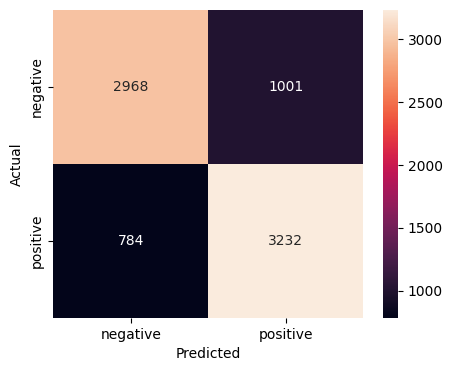

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

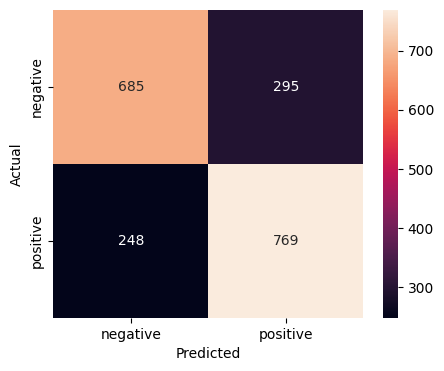

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

The confusion matrix shows better separation between positive and negative reviews than the Word2Vec-RF model, reflecting the richer sentence embeddings.

**Accuracy**

In [ ]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)

The accuracy on the training set is:  0.7764558547276142
The accuracy on the test set is:  0.728092138207311


Test accuracy has improved over Word2Vec-RF, showing that sentence-level embeddings help Random Forest generalize better to unseen reviews.

## **Sentiment Analysis with Neural Networks**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,666 (225.26 KB)

 Trainable params: 57,666 (225.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
    )

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7480 - loss: 0.5156 - val_accuracy: 0.7927 - val_loss: 0.4340
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8061 - loss: 0.4267 - val_accuracy: 0.8012 - val_loss: 0.4166
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8179 - loss: 0.4035 - val_accuracy: 0.7817 - val_loss: 0.4433
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8314 - loss: 0.3778 - val_accuracy: 0.8147 - val_loss: 0.4190
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8452 - loss: 0.3538 - val_accuracy: 0.8037 - val_loss: 0.4254
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8597 - loss: 0.3277 - val_accuracy: 0.8052 - val_loss: 0.4240
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8733 - loss: 0.3025 - val_accuracy: 0.8067 - val_loss: 0.4225
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8917 - loss: 0.2654 - val_accuracy: 0.

### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


**Confusion Matrix**

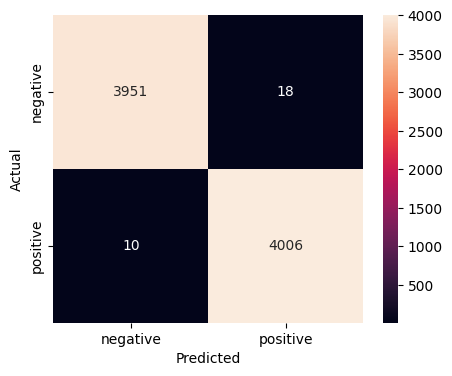

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

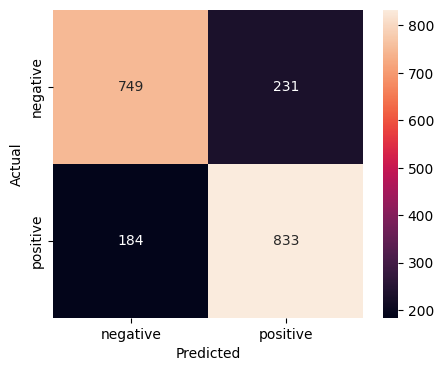

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

The confusion matrix shows very few errors here, but that alone doesn't confirm a great model - it needs to be checked against training performance for overfitting.

**Accuracy**

In [ ]:
train_accuracy_transformer_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the training set is: ",train_accuracy_transformer_NN)
test_accuracy_transformer_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_transformer_NN)

The accuracy on the training set is:  0.9964934251721979
The accuracy on the test set is:  0.7921882824236355


Training accuracy is noticeably higher than test accuracy, a sign of overfitting - the model fits the training data closely but generalizes less well.

# **Model Perfomance Comparison**

In [ ]:
# Create a dictionary to compare different models and their accuracies
model_comp = {
    'Model': [
        'Word2Vec-RF',
        'Sentence-Transformer-RF',
        'Word2Vec-NN',
        'Sentence-Transformer-NN'
    ],
    'Train Accuracy': [
        train_accuracy_Word2Vec_RF,
        train_accuracy_transformer_RF,
        train_accuracy_Word2Vec_NN,
        train_accuracy_transformer_NN
    ],
    'Test Accuracy': [
        test_accuracy_Word2Vec_RF,
        test_accuracy_transformer_RF,
        test_accuracy_Word2Vec_NN,
        test_accuracy_transformer_NN
    ]
}

# Creating the DataFrame
model_comp_df = pd.DataFrame(model_comp)

model_comp_df

,Model,Train Accuracy,Test Accuracy
0,Word2Vec-RF,0.664371,0.644967
1,Sentence-Transformer-RF,0.776456,0.728092
2,Word2Vec-NN,0.729117,0.711567
3,Sentence-Transformer-NN,0.996493,0.792188


This table lets us compare all four approaches side by side on both train and test accuracy, helping us pick the model that generalizes best rather than the one with the highest train score alone.

<center><p float="center">
  <img src="https://i.postimg.cc/kXqnZ73y/Observations-Diagram.jpg" width=800></a>

# **Best Model Selection and Test Data Performance**

**Sentence-Transformer-RF** is best because Sentence Transformers capture full sentence context, leading to richer embeddings. This allows them to achieve higher test accuracies and better generalization compared to **Word2Vec** based models.

In [ ]:
from sentence_transformers import SentenceTransformer

# Re-initialize the SentenceTransformer for encoding new data, as the 'model' variable was overwritten by the Keras NN model
s_transformer_encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')


# Example unseen reviews
unseen_review_positive = "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat. Highly recommend!"
unseen_review_negative = "Terrible movie, a complete waste of time. The story was boring and the characters were unconvincing."

def predict_sentiment_rf(review_text):
    # Encode the unseen review using the SentenceTransformer
    unseen_review_embedding = s_transformer_encoder.encode([review_text])

    # Predict sentiment using the 'rf_transformer' model
    predicted_sentiment_index = rf_transformer.predict(unseen_review_embedding)[0]

    sentiment_labels = {0: 'negative', 1: 'positive'}
    predicted_sentiment_label = sentiment_labels[predicted_sentiment_index]

    print(f"\nReview: '{review_text}'")
    print(f"Predicted Sentiment (RF): {predicted_sentiment_label}")

predict_sentiment_rf(unseen_review_positive)
predict_sentiment_rf(unseen_review_negative)


Review: 'This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat. Highly recommend!'
Predicted Sentiment (RF): positive

Review: 'Terrible movie, a complete waste of time. The story was boring and the characters were unconvincing.'
Predicted Sentiment (RF): negative


# **Conclusion**

<center><p float="center">
  <img src="https://i.postimg.cc/gJW5JkDF/Conclusion-Diagram.jpg" width=800></a>

# <font size=5 color='skyblue'>**Thank You!**</font>
___